In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import adjusted_rand_score
import pandas as pd 


# Load the wine dataset
wine = load_wine()

# Extract features and target variable
X = wine.data
y = wine.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

frame = pd.DataFrame(X_train_scaled)
print(frame)

# Define the number of clusters
k = 3

# Initialize KMeans model
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit the model to the scaled training data
kmeans.fit(X_train_scaled)

# Get cluster labels for the training set
train_labels = kmeans.labels_


           0         1         2         3         4         5         6   \
0    1.665293 -0.608406  1.218962  1.605400 -0.167384  0.804002 -0.691678   
1   -0.549525  2.751541  1.003315  1.605400 -0.304379 -0.785384 -1.401233   
2   -0.745310 -1.143541 -0.937507 -0.282704 -0.852357  1.937029  1.746791   
3    0.612948 -0.617179  1.003315  0.879206 -0.783860  0.489272 -0.901547   
4    0.111249 -0.766315 -0.937507 -1.154137 -0.167384  0.174542  0.637487   
..        ...       ...       ...       ...       ...       ...       ...   
137  1.077938 -0.757542  1.111138  1.605400 -0.989352  1.040049  0.857349   
138 -0.892149 -0.564542 -0.865625 -0.137465 -1.400336 -1.005695  0.027870   
139  1.714239 -0.441724  0.068845 -2.170809  0.106605  1.590826  1.636860   
140 -0.353740 -0.739996 -0.362449  0.356346 -1.400336 -1.430580 -0.541773   
141 -0.782020  0.067093  0.356374  0.443490 -0.167384  0.426326  0.107820   

           7         8         9         10        11        12  
0    1.26

Silhouette Score on Training Set: 0.1867312113152357
Adjusted Rand Index on Training Set: 0.8919536738815038


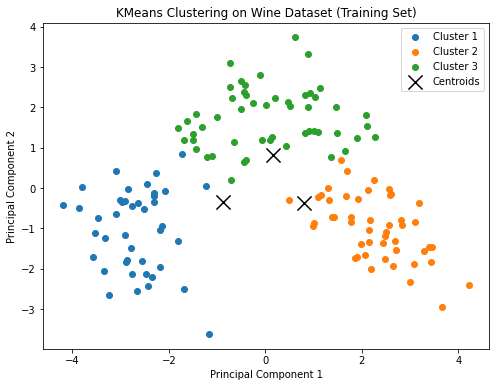

In [2]:
# Compute silhouette score on the training set
silhouette_train = silhouette_score(X_train, train_labels)
print(f"Silhouette Score on Training Set: {silhouette_train}")
adj_ari = adjusted_rand_score(y_train, train_labels)
print(f"Adjusted Rand Index on Training Set: {adj_ari}")

# Get cluster centroids for the training set
centroids_train = kmeans.cluster_centers_

# Visualize the clusters (2D PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))

for i in range(k):
    plt.scatter(X_train_pca[train_labels == i, 0], X_train_pca[train_labels == i, 1], label=f'Cluster {i+1}')

plt.scatter(centroids_train[:, 0], centroids_train[:, 1], marker='x', s=200, c='black', label='Centroids')
plt.title('KMeans Clustering on Wine Dataset (Training Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()